# Computational Statistical Mechanics - pamuduamarasinghe

# 1. Markov-Ising Algorithm

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit



@njit
def energy(spins):

    L = spins.shape[0]
    E = 0

    for i in range(L):
        for j in range(L):

            E -= spins[i, j] * (
                spins[(i + 1) % L, j] +
                spins[i, (j + 1) % L]
            )

    return E



@njit
def magnetization(spins):

    return abs(np.sum(spins))


@njit
def metropolis(spins, beta):

    L = spins.shape[0]

    for _ in range(L * L):

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        # Four nearest neighbours
        neighbors = (
            spins[(i - 1) % L, j] +
            spins[(i + 1) % L, j] +
            spins[i, (j - 1) % L] +
            spins[i, (j + 1) % L]
        )

        dE = 2 * spins[i, j] * neighbors

        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):

            spins[i, j] *= -1

    return spins



# ISING SIMULATION
@njit
def simulate(L, beta, steps):

    spins = np.random.choice(np.array([-1, 1]), size=(L, L))

    energies = np.zeros(steps)
    magnetizations = np.zeros(steps)


    for _ in range(200):
        spins = metropolis(spins, beta)

    for i in range(steps):

        spins = metropolis(spins, beta)

        energies[i] = energy(spins)
        magnetizations[i] = magnetization(spins) / (L * L)


    E_mean = np.mean(energies)
    M_mean = np.mean(magnetizations)

    E2_mean = np.mean(energies ** 2)
    Cv = beta**2 * (E2_mean - E_mean**2) / (L * L)

    return E_mean, M_mean, Cv



FOR 4x4 AND 32x32 lattice

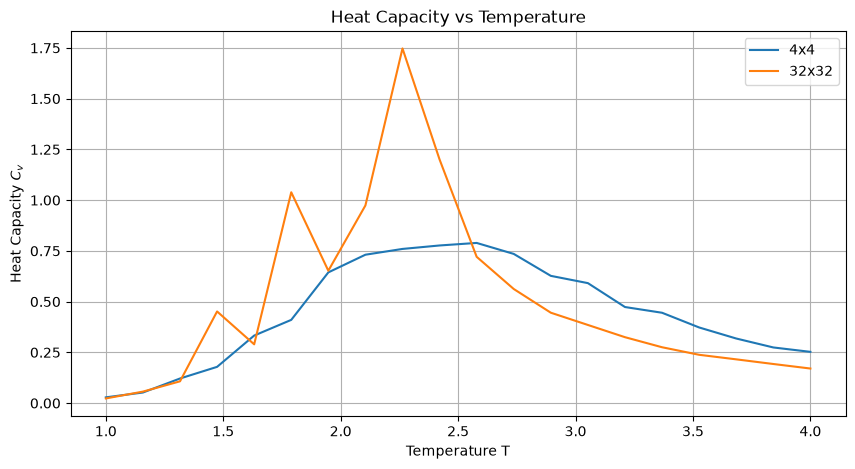

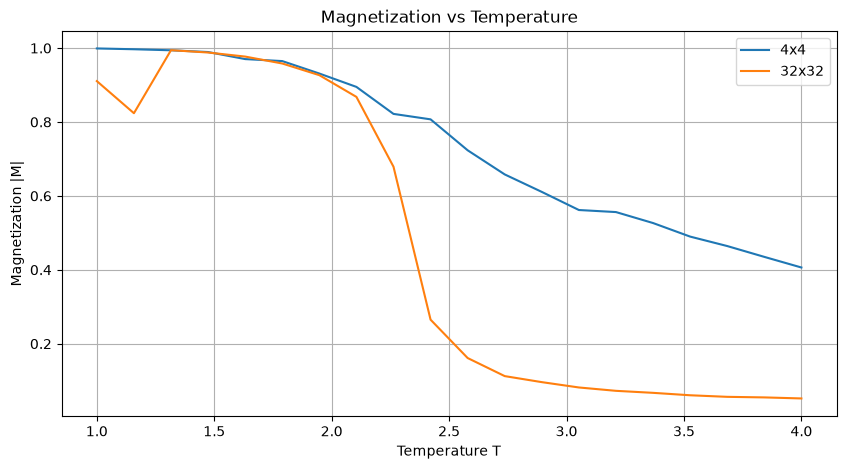

In [ ]:
L_values = [4, 32]
T_values = np.linspace(1, 4, 20)

plt.figure(figsize=(10, 5))

for L in L_values:

    Cv_values = []

    for T in T_values:

        beta = 1 / T

        if L == 4:
            steps = 2000
        else:
            steps = 20000

        E, M, Cv = simulate(L, beta, steps)
        Cv_values.append(Cv)

    plt.plot(T_values, Cv_values, label=f'{L}x{L}')


plt.xlabel('Temperature T')
plt.ylabel('Heat Capacity $C_v$')
plt.title('Heat Capacity vs Temperature')
plt.grid(True)
plt.legend()
plt.show()



plt.figure(figsize=(10, 5))

for L in L_values:

    M_values = []

    for T in T_values:

        beta = 1 / T

        if L == 4:
            steps = 2000
        else:
            steps = 20000

        E, M, Cv = simulate(L, beta, steps)
        M_values.append(M)

    plt.plot(T_values, M_values, label=f'{L}x{L}')


plt.xlabel('Temperature T')
plt.ylabel('Magnetization |M|')
plt.title('Magnetization vs Temperature')
plt.grid(True)
plt.legend()
plt.show()

